In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# The activity coefficient of a protein &mdash; hemoglobin in water

**Illustration 9.7-1.**

Section 9.7 is about mixtures the rest of the chapter cannot handle. Every model in
Sections 9.5 and 9.6 refers each species to itself as a pure liquid at the temperature
and pressure of the mixture. A protein has no such state: hemoglobin does not exist as
a pure liquid, and no amount of extrapolation invents one. So its activity coefficient
is defined on a **Henry's law basis** instead, referred to infinite dilution in the
solvent, and its composition is measured as a concentration rather than a mole
fraction:

$$\gamma(c) = \frac{a(c)}{c}, \qquad \gamma \to 1 \ \text{as}\ c \to 0$$

with $a$ and $c$ both in g/L. That is the whole of what this illustration asks for
&mdash; but the way it asks for it is worth dwelling on, because **it is a fitting
problem, and the illustration reports a fit without reporting how it was obtained.**

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo import (LogPolynomialActivity, ILLUSTRATION_9_7_1_HEMOGLOBIN,
                    SIS_9_7_1_CONSTANTS)
from thermo.charts import use_book_style
use_book_style()

c, a = ILLUSTRATION_9_7_1_HEMOGLOBIN.T
gamma = a / c

## First: the printed table checks itself

The illustration prints $c$ and $a$ in the question and $\gamma$ in the solution, and
$\gamma = a/c$ is an *identity*, not a model. So the solution's third column is a
check on the transcription of the first two &mdash; the same trick that found printed
typos in Appendix A.III. Nothing here is fitted yet.

In [3]:
printed = np.array([1.155, 1.337, 1.577, 1.875, 2.260, 2.750, 3.379, 4.244,
                    5.406, 7.050, 9.364, 12.67, 17.62, 25.14, 36.83])

print(f"{'c (g/L)':>8} {'a (g/L)':>9} {'printed':>9} {'a/c':>9} {'diff':>7}")
for ci, ai, gi, pi in zip(c, a, gamma, printed):
    print(f"{ci:8.0f} {ai:9.1f} {pi:9.4g} {gi:9.4f} {100*(pi-gi)/gi:6.2f}%")

worst = np.abs((printed - gamma) / gamma).max()
print(f"\nworst disagreement with the identity gamma = a/c: {100*worst:.2f}%")

 c (g/L)   a (g/L)   printed       a/c    diff
      20      23.1     1.155    1.1550   0.00%
      40      53.5     1.337    1.3375  -0.04%
      60      94.6     1.577    1.5767   0.02%
      80     150.0     1.875    1.8750   0.00%
     100     226.0      2.26    2.2600   0.00%
     120     330.0      2.75    2.7500   0.00%
     140     473.0     3.379    3.3786   0.01%
     160     679.0     4.244    4.2438   0.01%
     180     973.0     5.406    5.4056   0.01%
     200    1410.0      7.05    7.0500   0.00%
     220    2060.0     9.364    9.3636   0.00%
     240    3040.0     12.67   12.6667   0.03%
     260    4580.0     17.62   17.6154   0.03%
     280    7040.0     25.14   25.1429  -0.01%
     300   11050.0     36.83   36.8333  -0.01%

worst disagreement with the identity gamma = a/c: 0.04%


&#11088; **All fifteen rows agree to rounding**, the worst by 0.04%. The printed data
are sound and can be used as they stand.

## The correlation, and the constants the book does not quite give you

The illustration fits

$$\ln\gamma = A c + B c^2 + C c^3 \tag{9.7-21}$$

There is deliberately no constant term: $\gamma \to 1$ as $c \to 0$ is then satisfied
by construction rather than by a fitted parameter that ought to come out zero.

The printed solution gives the fitted equation but says nothing about **how** it was
fitted, and that turns out to matter more than it looks.

In [4]:
book = LogPolynomialActivity(SIS_9_7_1_CONSTANTS)
print(book.report(c, gamma, "book, as printed"))

book, as printed           A=7.1390e-03  B=6.9400e-06  C=3.1160e-08   [as printed]  max|d|= 0.79%  rms= 0.35%


So the printed constants reproduce the data to 0.79% at worst. That is a good fit.

But $\gamma$ runs from 1.16 to 36.8 &mdash; a factor of 32 &mdash; so **least squares
on $\gamma$ and least squares on $\ln\gamma$ are not the same problem.** A fit to
$\gamma$ is dominated by the last three points, where $\gamma$ is largest; a fit to
$\ln\gamma$ weights all fifteen equally. The illustration does not say which was
done, so try both.

In [5]:
fits = {
    "refit, on ln gamma": LogPolynomialActivity.fit(c, gamma, 3, "ln gamma"),
    "refit, on gamma":    LogPolynomialActivity.fit(c, gamma, 3, "gamma"),
}
print(book.report(c, gamma, "book, as printed"))
for label, f in fits.items():
    print(f.report(c, gamma, label))

book, as printed           A=7.1390e-03  B=6.9400e-06  C=3.1160e-08   [as printed]  max|d|= 0.79%  rms= 0.35%
refit, on ln gamma         A=7.0789e-03  B=7.3253e-06  C=3.0432e-08   [ln gamma ]  max|d|= 0.60%  rms= 0.25%
refit, on gamma            A=7.1931e-03  B=6.2545e-06  C=3.2798e-08   [gamma    ]  max|d|= 0.91%  rms= 0.32%


&#11088; **Two things worth seeing here.**

**The objective moves the coefficients by more than the fit quality does.** $B$ changes
by about 15% between the two objectives and $C$ by about 8%, while the worst-case error
only moves between 0.6% and 0.9%. The correlation is much better determined than its
individual coefficients are &mdash; the terms trade against one another.

**The printed constants are not the optimum of either objective.** Both refits sit
between them, and least squares on $\ln\gamma$ does better than the printed constants
on both measures. That is not an error in the book: a fit made graphically, or with
another package's default weighting, lands exactly here. &#9888; **It does mean the
printed constants should not be treated as a target to be reproduced** &mdash; a
notebook that tuned itself until it recovered `6.940e-6` would be fitting the typography
rather than the data.

## Does the cubic term earn its place?

$C$ is the least determined of the three, and the data span only 20 to 300 g/L. The
honest way to ask is to drop it and look.

In [6]:
for order in (2, 3, 4):
    f = LogPolynomialActivity.fit(c, gamma, order, "ln gamma")
    print(f.report(c, gamma, f"order {order}, on ln gamma"))

order 2, on ln gamma       A=5.9160e-03  B=1.9869e-05   [ln gamma ]  max|d|= 4.25%  rms= 2.29%
order 3, on ln gamma       A=7.0789e-03  B=7.3253e-06  C=3.0432e-08   [ln gamma ]  max|d|= 0.60%  rms= 0.25%
order 4, on ln gamma       A=6.9271e-03  B=1.0281e-05  C=1.3652e-08  D=2.9019e-11   [ln gamma ]  max|d|= 0.37%  rms= 0.19%


&#11088; **It earns it, and a fourth term does not.** Dropping to two terms costs a
factor of seven in the worst-case error &mdash; 4.3% against 0.6% &mdash; far outside
the scatter of the data, so the cubic term is doing real work.

Adding a fourth term is the more interesting case, because it *does* improve the fit,
from 0.60% to 0.37%. The reason to refuse it is not the residual but what it does to
the coefficients: $B$ jumps by 40% and $C$ falls by more than half, to accommodate a
$D$ that is physically meaningless on this range. **When adding a term makes the
existing coefficients swing by far more than the fit improves, the extra term is
absorbing noise, not structure.** Three terms is the right number, and the
illustration's choice is vindicated for a reason the illustration does not give.

## The print figure

Illustration 9.7-1's plot: $\gamma$ against $c$, with the fifteen data points and the
correlation through them. The axes, ranges and marker style follow the 5e art
(`c09uf001.jpg` in the 5e figure set &mdash; see the note below about its numbering).

&#9888; **The curve is drawn from the printed constants, not from the refit.** The
printed equation stays in the illustration, so the printed figure must agree with it;
changing one without the other would leave the page inconsistent with itself.

wrote pdf/Illustration_9.7-1.pdf


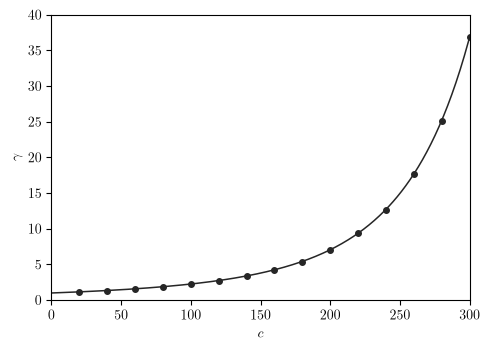

In [7]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))
cc = np.linspace(0, 300, 400)

ax.plot(cc, book.gamma(cc), "-", color="0.15", lw=1.1)
ax.plot(c, gamma, "o", color="0.15", ms=4)

ax.set_xlim(0, 300); ax.set_ylim(0, 40)
ax.set_xticks(np.arange(0, 301, 50)); ax.set_yticks(np.arange(0, 41, 5))
ax.set_xlabel(r"$c$"); ax.set_ylabel(r"$\gamma$")
fig.tight_layout()
fig.savefig("pdf/Illustration_9.7-1.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Illustration_9.7-1.pdf")

## What this notebook is for

Three things the printed illustration cannot show:

1. **The data check themselves.** $\gamma = a/c$ is an identity, so the solution's
   table is a transcription check on the question's, and all fifteen rows pass.
2. **The fit has an objective, and the objective is a choice.** Fitting $\ln\gamma$
   and fitting $\gamma$ give coefficients differing by up to 15%, on data neither fit
   describes to better than about half a percent. Any reported correlation constant is
   incomplete without the objective that produced it.
3. **The cubic term is necessary and a quartic is not** &mdash; which takes one line to
   demonstrate and no amount of staring at the printed equation to guess.

&#9888; **A note on the 5e art numbering, for anyone matching files to slots.** The
manuscript's unnumbered-figure slots and the 5e figure-set filenames are offset by one
in this chapter, because the figure set files the 2,2,4-trimethyl pentane structure
under `c09g004.jpg` while the manuscript calls that slot `c09uf001`. The hemoglobin
plot is slot `c09uf002` but file `c09uf001.jpg`, and Illustration 9.10-2's plot is slot
`c09uf003` but file `c09uf002.jpg`. **No unnumbered art is missing from this chapter**
&mdash; all three slots have 5e art. See `revision_notes/c09.md` §20.